# 04 — Telescopic OTA & Two-Stage Miller OTA

All devices built from scratch with `gl.nmos()` / `gl.pmos()` primitives.

```
 VDD ─── mp_ref ─── mp_copy
           |           |
          vleft       vout  ← single-ended output
           |           |
          mn_p ── mn_m  ← NMOS diff pair
              vtail
               mt          ← tail NMOS
 GND ──────────────────────
```

In [1]:
import sys, os
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
sys.path.insert(0, os.path.abspath('../../src/gelochip'))
import gelochip.gl as gl
gl.reload()  # pick up latest code without restarting kernel
print('Imports OK')

[gl] reloaded — DRC sweep active (with_tie=True by default)
Imports OK


## Telescopic OTA — 5 devices from scratch

2026-05-20 16:30:57.472 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active
2026-05-20 16:31:02.551 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/telescopicota.gds'


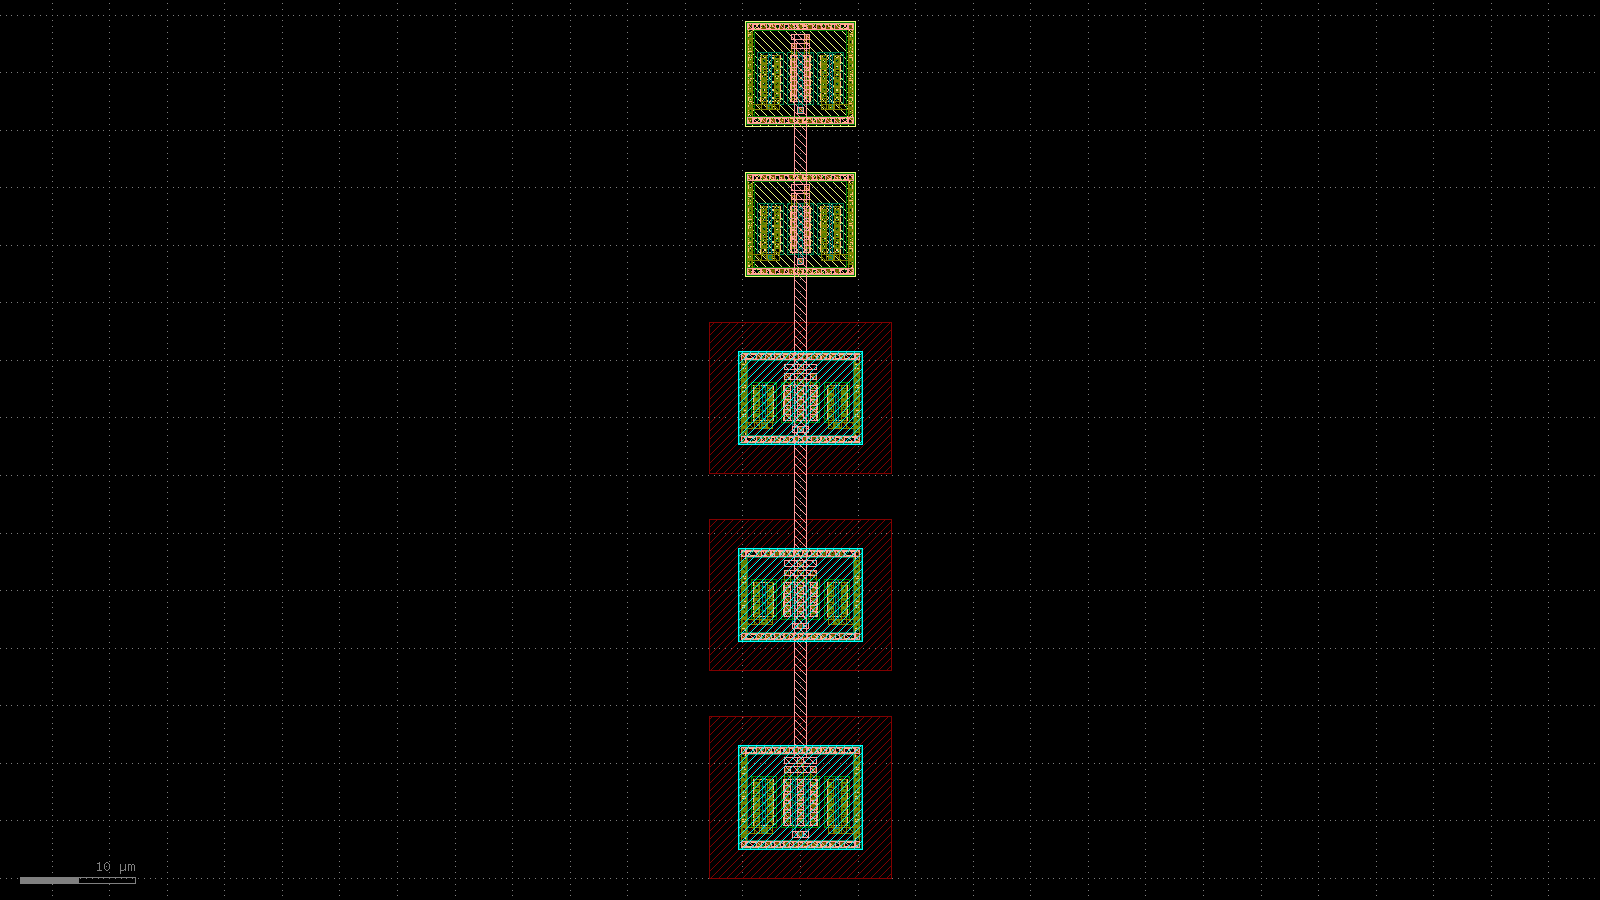

2026-05-20 16:31:02.718 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/irman/Gelochip/notebooks/gelo_dataset_optimized/TELESCOPICOTA.gds'


using provided pdk_root
Defaulting to stale magic_commands.tcl


2026-05-20 16:31:02.963 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmp7k1p6il6/TELESCOPICOTA.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmp9jl0b97m/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "TELESCOPICOTA".
[INFO]: Loading

{'converged': False, 'error': 'no netlist'}

In [2]:
class TelescopicOTA(gl.Module):
    def __init__(self, wn=3.0, wp=4.0, wt=4.0, fn=2):
        super().__init__(gl.gf180)
        self.wn, self.wp, self.wt, self.fn = wn, wp, wt, fn

    def layout(self):
        vip   = self.pin('vip')
        vim   = self.pin('vim')
        vbias = self.pin('vbias')
        vout  = self.pin('vout')
        vtail = gl.Net('vtail')
        vleft = gl.Net('vleft')   # PMOS reference node

        # Tail current source
        gl.nmos(w=self.wt, fingers=2, g=vbias, d=vtail, s=gl.gnd)

        # NMOS input diff pair
        gl.nmos(w=self.wn, fingers=self.fn, g=vip, d=vleft, s=vtail)
        gl.nmos(w=self.wn, fingers=self.fn, g=vim, d=vout,  s=vtail)

        # PMOS current-mirror load
        gl.pmos(w=self.wp, fingers=1, g=vleft, d=vleft, s=gl.vdd)  # diode-connected
        gl.pmos(w=self.wp, fingers=1, g=vleft, d=vout,  s=gl.vdd)  # mirror copy

ota = TelescopicOTA(wn=3, wp=4, wt=4, fn=2).build()
ota.show()
ota.drc()
ota.sim()

## Two-Stage Miller OTA — using `gl.Sequential`

Stage 1 = telescopic input stage, Stage 2 = common-source output.

2026-05-20 16:31:20.229 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/twostage_ota.gds'


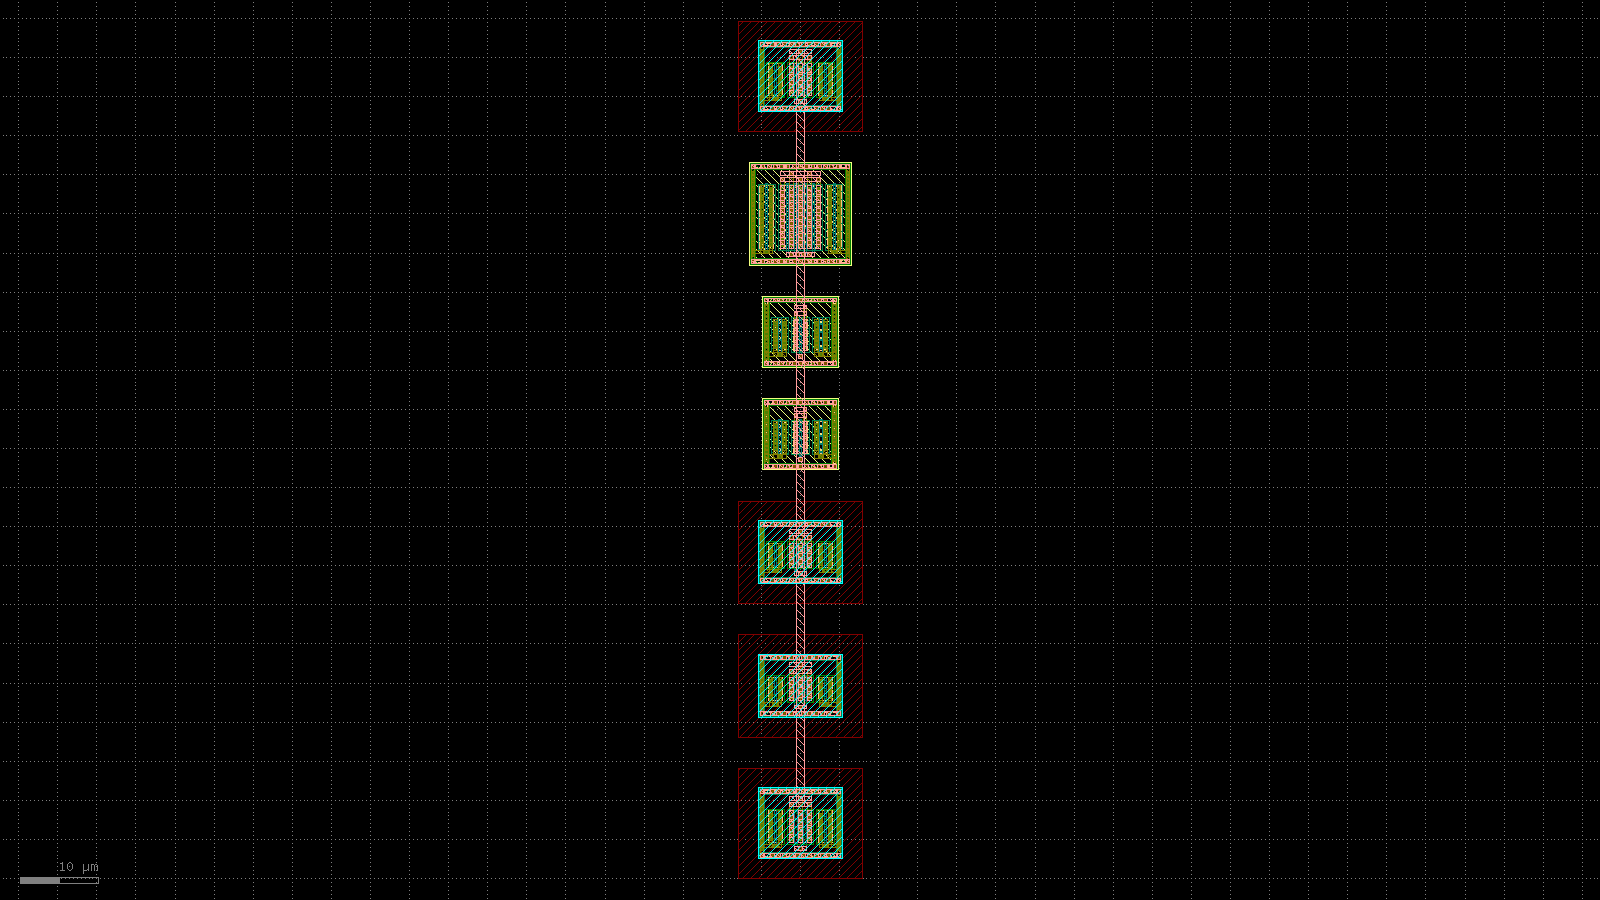

2026-05-20 16:31:20.277 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/irman/Gelochip/notebooks/gelo_dataset_optimized/TWOSTAGE_OTA.gds'


using provided pdk_root
Defaulting to stale magic_commands.tcl


2026-05-20 16:31:20.515 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmp9f9jo7bm/TWOSTAGE_OTA.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpvny__jkp/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "TWOSTAGE_OTA".
[INFO]: Loading 

{'converged': False, 'error': 'no netlist'}

In [3]:
class Stage1(gl.Module):
    def layout(self):
        vip   = self.pin('vip')
        vim   = self.pin('vim')
        vbias = self.pin('vbias1')
        vint  = self.pin('vint')    # inter-stage node
        vtail = gl.Net('vtail1')
        vleft = gl.Net('vleft1')

        gl.nmos(w=4.0, fingers=2, g=vbias, d=vtail, s=gl.gnd)
        gl.nmos(w=3.0, fingers=2, g=vip,   d=vleft, s=vtail)
        gl.nmos(w=3.0, fingers=2, g=vim,   d=vint,  s=vtail)
        gl.pmos(w=4.0, fingers=1, g=vleft, d=vleft, s=gl.vdd)
        gl.pmos(w=4.0, fingers=1, g=vleft, d=vint,  s=gl.vdd)


class Stage2(gl.Module):
    def layout(self):
        vint  = self.pin('vint')    # same name → auto-connects to Stage1
        vbias = self.pin('vbias2')
        vout  = self.pin('vout')

        gl.pmos(w=8.0, fingers=4, g=vint,  d=vout, s=gl.vdd)
        gl.nmos(w=4.0, fingers=2, g=vbias, d=vout, s=gl.gnd)


class TwoStageOTA(gl.Sequential):
    def __init__(self):
        super().__init__(Stage1(), Stage2(), pdk=gl.gf180)

ota2 = TwoStageOTA().build(name='twostage_ota')
ota2.show()
ota2.drc()
ota2.sim()